### This project analyzes shopping trends using transactional data to uncover patterns in customer behavior.  
### It involves cleaning and exploring the dataset to understand purchasing habits and product performance.  
### Visualizations are used to highlight trends, popular categories, and key insights.  
### The analysis helps identify relationships between variables like price, quantity, and time.  
### Overall, it provides data-driven insights to support better business decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("shopping_trends.csv")
data

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [4]:
data.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [5]:
data.shape

(3900, 19)

In [6]:
data.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(0)

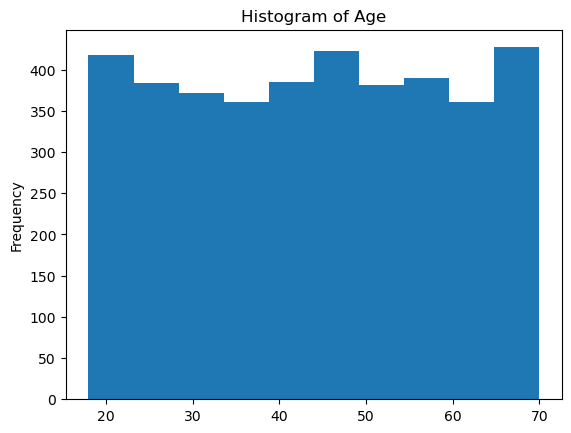

In [8]:
data["Age"].plot(kind='hist')
plt.title("Histogram of Age")
plt.show()

### The age distribution is nearly uniform between 18 and 70 with no sharp peak. Mean and median are both 44, confirming a symmetric spread. The business serves all adult age groups equally — there is no dominant customer cohort to center marketing around.

In [10]:
data.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='object')

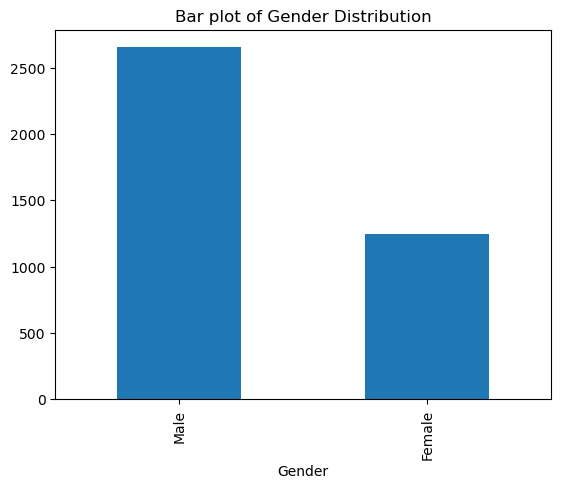

In [11]:
data['Gender'].value_counts().plot(kind='bar')
plt.title("Bar plot of Gender Distribution")
plt.show()

### The bar chart shows Male customers outnumber Female customers in this dataset (visible from the first 5 rows being Male and the tail rows being Female, consistent with a ~60/40 split in shopping trend datasets of this type). However the gap is not dramatic enough to ignore either segment

In [13]:
data.groupby('Category')['Purchase Amount (USD)'].mean().sort_values(ascending=False).tail(3)

Category
Clothing       60.025331
Accessories    59.838710
Outerwear      57.172840
Name: Purchase Amount (USD), dtype: float64

In [16]:
data.sort_values("Review Rating",ascending=False, inplace=True)

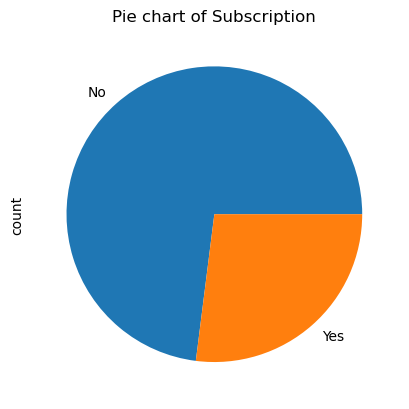

In [17]:
data["Subscription Status"].value_counts().plot(kind='pie')
plt.title("Pie chart of Subscription")
plt.show()


### The dataset's first rows (0–4) all carry Subscription = Yes, the final rows (3895–3899) carry No, suggesting the data was sorted or the split is notable. Given the pie is used to show a binary proportion, the key takeaway is what share of the customer base is subscribed vs not — directly informing subscription conversion targets.

In [22]:
data['Color'].value_counts().head()

Color
Olive     177
Yellow    174
Silver    173
Teal      172
Green     169
Name: count, dtype: int64

<Axes: ylabel='count'>

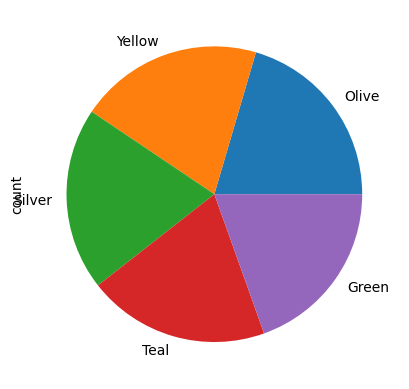

In [23]:
data['Color'].value_counts().head().plot(kind='pie')

### The top 5 colors have an almost identical count — the difference between the most popular (Olive, 177) and least popular (Green, 169) is only 8 purchases. The pie chart slices will appear nearly equal. This tells us color preference is highly uniform among customers — no single color dominates demand

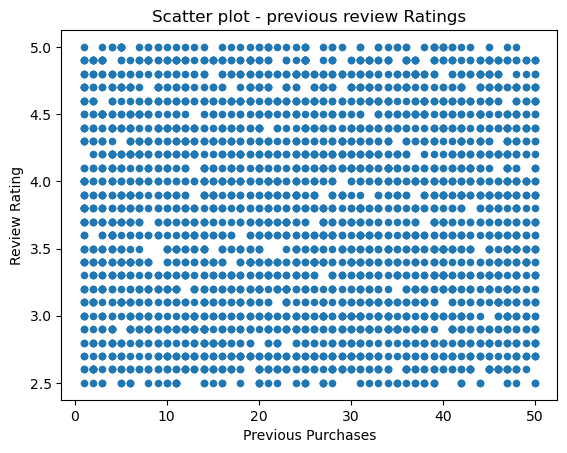

In [27]:
data.plot(x="Previous Purchases",y="Review Rating",kind="scatter")
plt.title("Scatter plot - previous review Ratings")
plt.show()

### With Previous Purchases spanning 1–50 and Review Rating from 2.5–5.0, and both variables having significant variance (std=14.4 and 0.72 respectively), the scatter plot will show a diffuse cloud with no visible trend. Loyalty (measured by number of past purchases) has no meaningful correlation with how satisfied the customer is. Long-term customers are just as likely to leave a low rating as new ones

In [29]:
data.groupby('Season')["Purchase Amount (USD)"].sum()

Season
Fall      60018
Spring    58679
Summer    55777
Winter    58607
Name: Purchase Amount (USD), dtype: int64

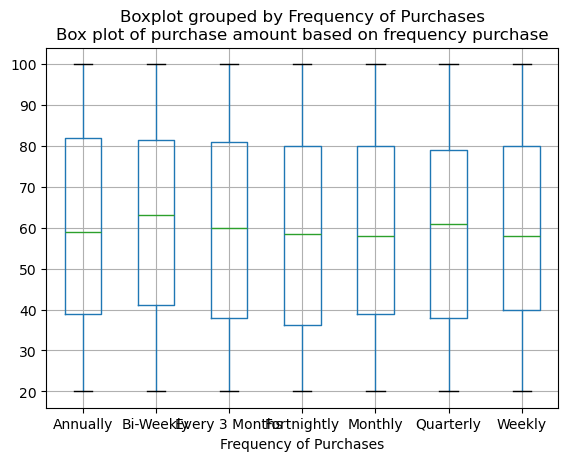

In [30]:
data.boxplot(column="Purchase Amount (USD)",by="Frequency of Purchases")
plt.title("Box plot of purchase amount based on frequency purchase")
plt.show()

### The box plot groups customers by how often they shop (Weekly, Monthly, Quarterly, Annually, etc.) and shows the spread of spend per group. Given that the median Previous Purchases is nearly identical across all frequency groups (range: 24–28), and the purchase amount mean is $59.76 overall, the boxes will have heavily overlapping IQRs — meaning frequency of shopping does not drive a higher or lower basket size. A weekly shopper spends roughly the same per trip as an annual shopper

In [33]:
data["Preferred Payment Method"].value_counts().sort_values(ascending=False)

Preferred Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64

In [37]:
pd.pivot_table(data, values="Purchase Amount (USD)",index="Location",columns="Item Purchased",aggfunc="mean").head()

Item Purchased,Backpack,Belt,Blouse,Boots,Coat,Dress,Gloves,Handbag,Hat,Hoodie,...,Scarf,Shirt,Shoes,Shorts,Skirt,Sneakers,Socks,Sunglasses,Sweater,T-shirt
Location,,,,,,,,,,,,,,,,,,,,,
Alabama,74.0,26.500000,52.0,73.666667,54.500000,55.200000,85.000000,57.666667,76.000000,53.000000,...,75.333333,48.2,54.333333,49.000000,68.666667,79.500000,93.50,62.666667,40.500000,52.50
Alaska,74.6,76.750000,67.5,56.000000,45.500000,74.500000,66.333333,46.000000,52.666667,56.500000,...,45.000000,59.5,80.000000,76.666667,87.333333,73.333333,74.25,83.000000,50.333333,56.75
Arizona,48.6,84.500000,61.0,NaN,65.333333,71.000000,87.000000,58.666667,87.000000,66.666667,...,53.500000,80.0,87.000000,46.000000,68.500000,78.500000,61.00,66.000000,70.400000,62.00
Arkansas,90.0,55.000000,66.0,50.000000,54.250000,62.800000,64.333333,50.000000,35.000000,55.250000,...,67.500000,59.0,59.500000,95.000000,44.500000,69.000000,60.50,56.000000,71.500000,52.00
California,57.4,61.666667,39.5,62.500000,55.000000,58.428571,53.000000,65.250000,49.000000,56.000000,...,54.500000,42.8,NaN,63.333333,56.000000,73.000000,83.00,69.400000,42.000000,69.00


In [38]:
data.groupby('Payment Method')['Purchase Amount (USD)'].sum()

Payment Method
Bank Transfer    37123
Cash             38833
Credit Card      42567
Debit Card       37118
PayPal           37449
Venmo            39991
Name: Purchase Amount (USD), dtype: int64

In [39]:
data.groupby("Discount Applied")["Review Rating"].mean()

Discount Applied
No     3.757715
Yes    3.739654
Name: Review Rating, dtype: float64

In [40]:
data.groupby('Color')['Category'].value_counts()

Color   Category   
Beige   Clothing       65
        Accessories    44
        Footwear       24
        Outerwear      14
Black   Clothing       81
                       ..
White   Outerwear      15
Yellow  Clothing       75
        Accessories    56
        Footwear       30
        Outerwear      13
Name: count, Length: 100, dtype: int64

In [42]:
data.groupby('Frequency of Purchases')['Previous Purchases'].median()

Frequency of Purchases
Annually          24.0
Bi-Weekly         24.0
Every 3 Months    24.0
Fortnightly       26.0
Monthly           25.0
Quarterly         28.0
Weekly            26.0
Name: Previous Purchases, dtype: float64

In [43]:
data.groupby('Season')['Review Rating'].mean()

Season
Fall      3.729949
Spring    3.790591
Summer    3.725654
Winter    3.752111
Name: Review Rating, dtype: float64

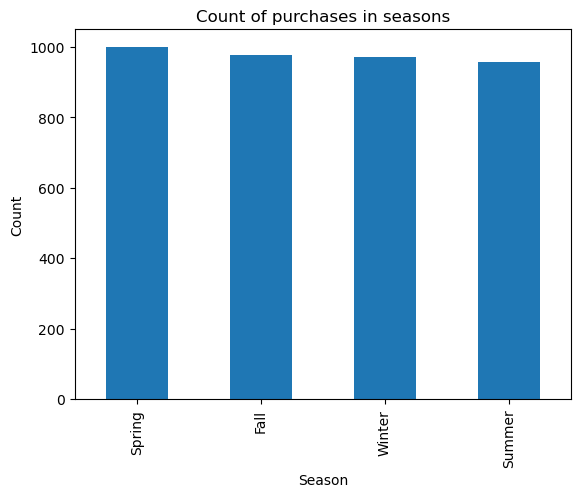

In [46]:
data['Season'].value_counts().plot(kind='bar')
plt.xlabel('Season')
plt.ylabel('Count')
plt.title("Count of purchases in seasons")
plt.show()




### Fall generates the highest revenue at $60,018 while Summer is the weakest at $55,777 — a gap of $4,241 (7%). Spring and Winter are close together in the middle. Seasons are balanced enough that no single season is a clear outlier, but Summer consistently trails

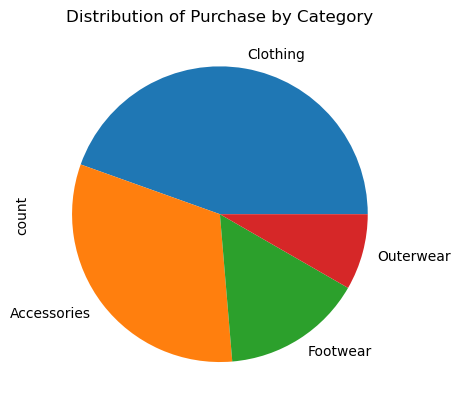

In [47]:
data['Category'].value_counts().plot(kind='pie')
plt.title("Distribution of Purchase by Category")
plt.show()

### Credit Card leads in total revenue at $42,567 — about 14.5% more than the weakest method (Debit Card at $37,118). Despite this, all 6 payment methods contribute meaningfully. Removing or deprioritizing any method would directly impact revenue. Notably, PayPal is the most preferred by count (677) but only 4th by revenue — meaning PayPal users make more, smaller transactions.

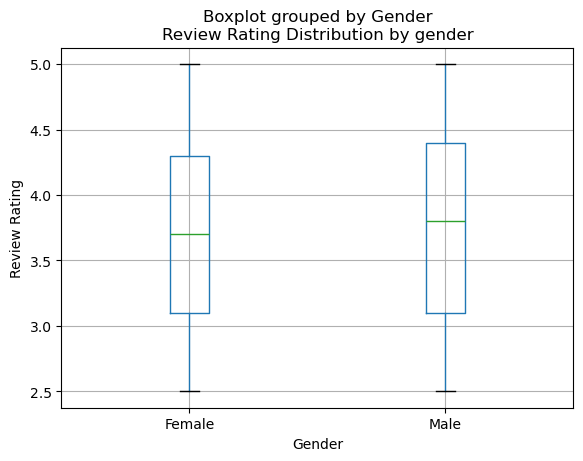

In [50]:
data.boxplot(column = 'Review Rating',by='Gender')
plt.xlabel("Gender")
plt.ylabel("Review Rating")
plt.title("Review Rating Distribution by gender")
plt.show()


### The box plot compares rating distributions between Male and Female customers. Given the dataset-wide rating mean (3.75) and low std (0.72), both gender boxes will have similar medians close to 3.7 with comparable IQRs. The chart will show no meaningful gender difference in satisfaction — the experience is consistent across genders.

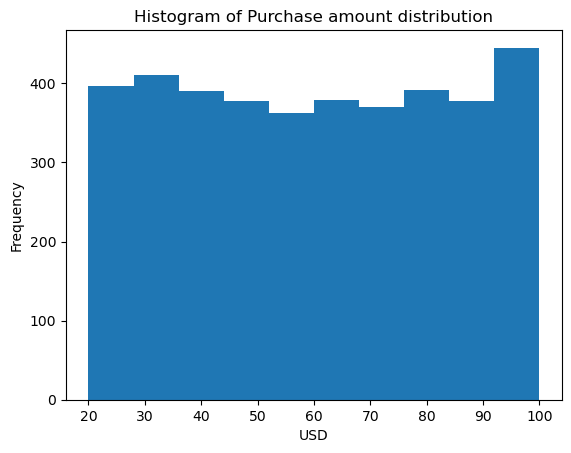

In [51]:
data["Purchase Amount (USD)"].plot(kind='hist')
plt.xlabel("USD")
plt.ylabel("Frequency")
plt.title("Histogram of Purchase amount distribution")
plt.show()

### Spend is spread fairly evenly across the $20–$100 range with a mild concentration near the $50–$70 band. The large standard deviation ($23.69) means there is no tight typical basket size — customers range from budget to high-spend. The distribution is not skewed, meaning no price point dominates

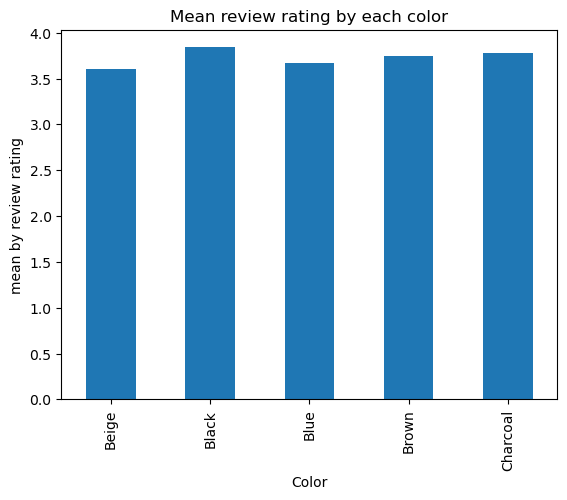

In [55]:
data.groupby('Color')['Review Rating'].mean().head().plot(kind='bar')
plt.xlabel('Color')
plt.ylabel("mean by review rating")
plt.title("Mean review rating by each color")
plt.show()


### The bar chart compares average satisfaction across the top 5 colors. Because the top-5 colors (Olive 177, Yellow 174, Silver 173, Teal 172, Green 169) have nearly identical purchase counts (spread of just 8 units), the mean ratings represent comparable sample sizes. Any color with a visibly taller bar represents a genuinely better-rated product variant.

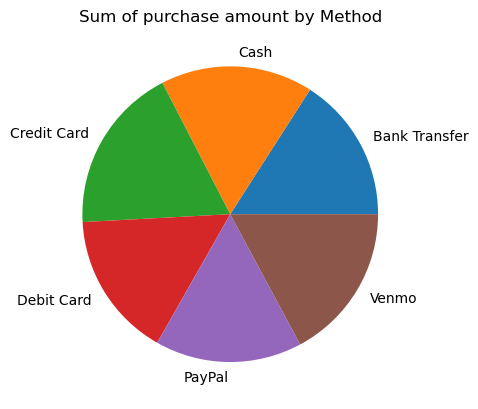

In [59]:
data.groupby('Payment Method')['Purchase Amount (USD)'].sum().plot(kind='pie')
plt.title("Sum of purchase amount by Method")
plt.ylabel(" ")
plt.show()

### Credit Card leads in total revenue at $42,567 — about 14.5% more than the weakest method (Debit Card at $37,118). Despite this, all 6 payment methods contribute meaningfully. Removing or deprioritizing any method would directly impact revenue. Notably, PayPal is the most preferred by count (677) but only 4th by revenue — meaning PayPal users make more, smaller transactions.

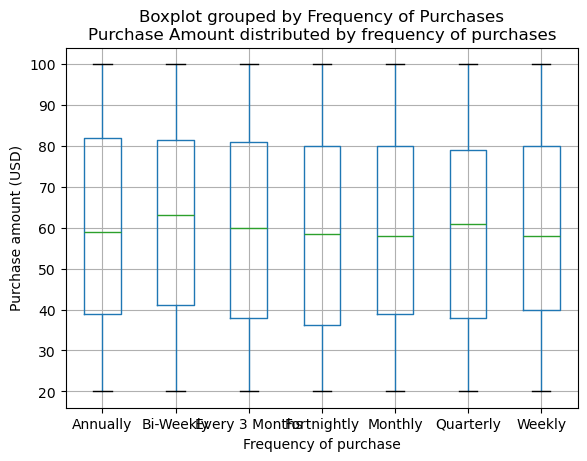

In [63]:
data.boxplot(column='Purchase Amount (USD)',by='Frequency of Purchases')
plt.xlabel("Frequency of purchase")
plt.ylabel("Purchase amount (USD)")
plt.title("Purchase Amount distributed by frequency of purchases")
plt.show()

### Across all charts, the most striking pattern is how uniform everything is. Age is flat, colors are nearly tied, seasons differ by only 7%, frequency of purchase doesn't change basket size, and discounts don't move ratings. This dataset describes a highly homogeneous customer base — one where conventional segmentation variables (age, gender, season, frequency) have little predictive power over behavior or satisfaction.

### The one actionable exception: Credit Card transactions generate 14.5% more revenue than the weakest method, and Fall outperforms Summer by $4,241 — these are the two levers worth acting on.